# Demonstrate CT Images - Corrupted Images vs. GT

Here we visualize CT images with different impairments:

*   **Metal Artifacts Corruption**
*   **Low Dose Images**

Every impairment type describes CT images from a different data set. The deep nn models objective is, when given an impaired CT image (the input), to produce a CT image that has a better quality than the impaired image (measured by metrics such as PSNR, SSIM), when they are compared with the ground truth (the label).

**Note**: the notbook assumes the running is in Google Colab, and that the example images were uploaded to local Files.

In [14]:
!pip install pydicom

import numpy as np
import matplotlib.pyplot as plt
import pydicom

In [15]:
file_path1 = r"/content/training_body_nometal_img12100_512x512x1.raw"
file_path2 = r"/content/training_body_metalart_img12100_512x512x1.raw"

raw_data1 = np.fromfile(file_path1, dtype=np.float32)
raw_data2 = np.fromfile(file_path2, dtype=np.float32)

image_matrix1 = raw_data1.reshape((512, 512))
image_matrix2 = raw_data2.reshape((512, 512))

# 2. Define the standard CT Soft Tissue Window
# Center = 40 HU, Width = 400 HU
window_center = 40
window_width = 400

# Calculate the display bounds
vmin = window_center - (window_width / 2)  # -160
vmax = window_center + (window_width / 2)  # +240

In [18]:
file_path3 = r"/content/L067_FD_3_1.CT.0002.0001.2015.12.22.18.12.07.5968.358090401.IMA"
file_path4 = r"/content/L067_QD_3_1.CT.0004.0001.2015.12.22.18.12.56.428910.358293547.IMA"

dicom_data1 = pydicom.dcmread(file_path3)
dicom_data2 = pydicom.dcmread(file_path4)

image_array1 = dicom_data1.pixel_array
image_array2 = dicom_data2.pixel_array


# 1. Convert raw pixel data to Hounsfield Units (HU)
intercept1 = dicom_data1.RescaleIntercept
slope1 = dicom_data1.RescaleSlope
hu_image1 = (image_array1 * slope1) + intercept1

intercept2 = dicom_data2.RescaleIntercept
slope2 = dicom_data2.RescaleSlope
hu_image2 = (image_array2 * slope2) + intercept2

# 2. Define standard CT Soft Tissue Window (Center = 40, Width = 400)
window_center = 40
window_width = 400

# Calculate the min and max display bounds based on the window
vmin = window_center - (window_width / 2)  # -160 HU
vmax = window_center + (window_width / 2)  # +240 HU

PLOTS

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

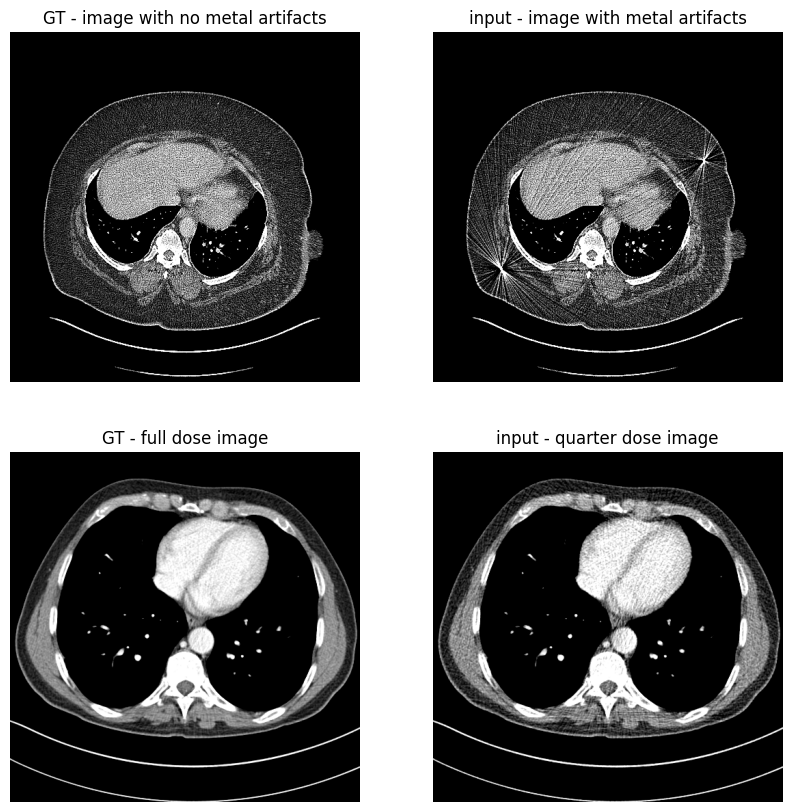

In [20]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(image_matrix1, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("GT - image with no metal artifacts")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(image_matrix2, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("input - image with metal artifacts")
plt.axis('off')

# 3. Plot the image using vmin and vmax to lock the contrast
plt.subplot(2, 2, 3)
plt.imshow(hu_image1, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("GT - full dose image")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(hu_image2, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("input - quarter dose image")
plt.axis('off')